
Amazon Review Score Prediction using NLP and Regression:
This project builds regression models to predict Amazon review scores using
text data and engineered features. TF-IDF is used to convert review text into
numerical features, and models are evaluated using MAE, RMSE, and R².


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import hstack, csr_matrix

In [3]:
df = pd.read_csv('/Reviews.csv')

print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
predictive_variables = ['Score', 'Summary', 'Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator']
df = df[predictive_variables].copy()

print(df.shape)
df.head()

(568454, 5)


,Score,Summary,Text,HelpfulnessNumerator,HelpfulnessDenominator
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1,1
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0,0
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,1,1
3,2,Cough Medicine,If you are looking for the secret ingredient i...,3,3
4,5,Great taffy,Great taffy at a great price. There was a wid...,0,0


In [5]:
df = df.dropna(subset=['Score', 'Text'])

df['Summary'] = df['Summary'].fillna('')

df['combined_text'] = df['Summary'] + ' ' + df['Text']

df['review_length'] = df['combined_text'].str.len()

df['helpfulness_ratio'] = np.where(
    df['HelpfulnessDenominator'] > 0,
    df['HelpfulnessNumerator'] / df['HelpfulnessDenominator'],
    0)

print(df.shape)
df.head()

(568454, 8)


,Score,Summary,Text,HelpfulnessNumerator,HelpfulnessDenominator,combined_text,review_length,helpfulness_ratio
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1,1,Good Quality Dog Food I have bought several of...,285,1.0
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0,0,Not as Advertised Product arrived labeled as J...,208,0.0
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,1,1,"""Delight"" says it all This is a confection tha...",531,1.0
3,2,Cough Medicine,If you are looking for the secret ingredient i...,3,3,Cough Medicine If you are looking for the secr...,234,1.0
4,5,Great taffy,Great taffy at a great price. There was a wid...,0,0,Great taffy Great taffy at a great price. The...,152,0.0


In [7]:
sample_size = 25000
amazon_sample = df.sample(n=sample_size, random_state=999)

print(amazon_sample.shape)
amazon_sample.head()

(25000, 8)


,Score,Summary,Text,HelpfulnessNumerator,HelpfulnessDenominator,combined_text,review_length,helpfulness_ratio
552558,4,Not sweet like other flavors,For habitual coffee drinkers who like that pic...,0,0,Not sweet like other flavors For habitual coff...,554,0.0
41632,5,Warheads,Great Candy! Best sour candy ever tried. * Do...,0,0,Warheads Great Candy! Best sour candy ever tr...,149,0.0
17947,5,Great for COOKING.,This is really hard to get to the right consis...,1,1,Great for COOKING. This is really hard to get ...,279,1.0
421398,5,At this price point this is great,It's a little hard to get out just one sheet a...,3,3,At this price point this is great It's a littl...,295,1.0
280047,5,Dave's Ghost Pepper Jolokia Private Reserve,"This stuff is the best. A dot of this stuff, ...",19,19,Dave's Ghost Pepper Jolokia Private Reserve Th...,417,1.0


Score
1     2425
2     1304
3     1899
4     3496
5    15876
Name: count, dtype: int64


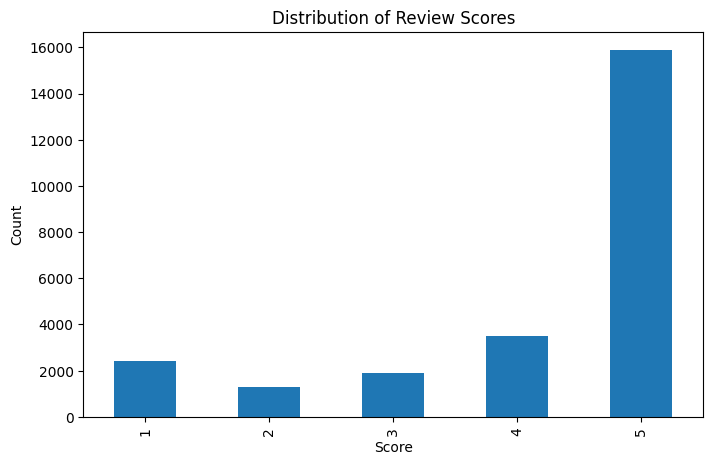

In [8]:
print(amazon_sample['Score'].value_counts().sort_index())

plt.figure(figsize=(8,5))
amazon_sample['Score'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

Score
1    527.075464
2    523.273773
3    544.117957
4    518.045195
5    427.059209
Name: review_length, dtype: float64


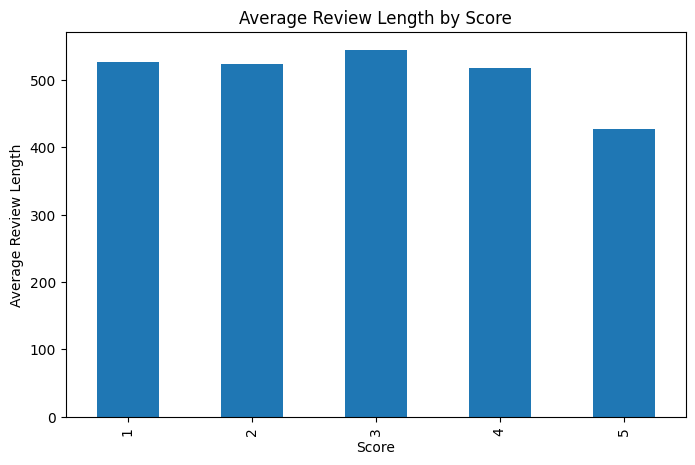

In [9]:
avg_length = amazon_sample.groupby('Score')['review_length'].mean()
print(avg_length)

plt.figure(figsize=(8,5))
avg_length.plot(kind='bar')
plt.title('Average Review Length by Score')
plt.xlabel('Score')
plt.ylabel('Average Review Length')
plt.show()

In [11]:
x_text = amazon_sample['combined_text']
x_numeric = amazon_sample[['review_length', 'helpfulness_ratio']]
y = amazon_sample['Score']

In [13]:
x_text_train, x_text_test, x_num_train, x_num_test, y_train, y_test = train_test_split(
    x_text,
    x_numeric,
    y,
    test_size=0.2,
    random_state=999
)

print(x_text_train.shape, x_text_test.shape)
print(x_num_train.shape, x_num_test.shape)

(20000,) (5000,)
(20000, 2) (5000, 2)


In [14]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=3000
)

x_text_train_tfidf = tfidf.fit_transform(x_text_train)
x_text_test_tfidf = tfidf.transform(x_text_test)

print(x_text_train_tfidf.shape)
print(x_text_test_tfidf.shape)

(20000, 3000)
(5000, 3000)


In [15]:
x_num_train_sparse = csr_matrix(x_num_train.values)
x_num_test_sparse = csr_matrix(x_num_test.values)

x_train_final = hstack([x_text_train_tfidf, x_num_train_sparse])
x_test_final = hstack([x_text_test_tfidf, x_num_test_sparse])

print(x_train_final.shape)
print(x_test_final.shape)

(20000, 3002)
(5000, 3002)


In [16]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Performance")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline Performance
MAE:  1.0587
RMSE: 1.3253
R²:   -0.0000


In [18]:
lin_reg = LinearRegression()
lin_reg.fit(x_train_final, y_train)

lin_pred = lin_reg.predict(x_test_final)

lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))
lin_r2 = r2_score(y_test, lin_pred)

print("Linear Regression Performance")
print(f"MAE:  {lin_mae:.4f}")
print(f"RMSE: {lin_rmse:.4f}")
print(f"R²:   {lin_r2:.4f}")

Linear Regression Performance
MAE:  0.7335
RMSE: 0.9631
R²:   0.4719


In [19]:
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(x_train_final, y_train)

ridge_pred = ridge_reg.predict(x_test_final)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print(f"MAE:  {ridge_mae:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²:   {ridge_r2:.4f}")

Ridge Regression Performance
MAE:  0.7140
RMSE: 0.9401
R²:   0.4968


In [20]:
analysis = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Ridge Regression'],
    'MAE': [baseline_mae, lin_mae, ridge_mae],
    'RMSE': [baseline_rmse, lin_rmse, ridge_rmse],
    'R2': [baseline_r2, lin_r2, ridge_r2]
})

analysis

,Model,MAE,RMSE,R2
0,Baseline,1.058741,1.325300,-0.000017
1,Linear Regression,0.733474,0.963127,0.471864
2,Ridge Regression,0.713973,0.940097,0.496819


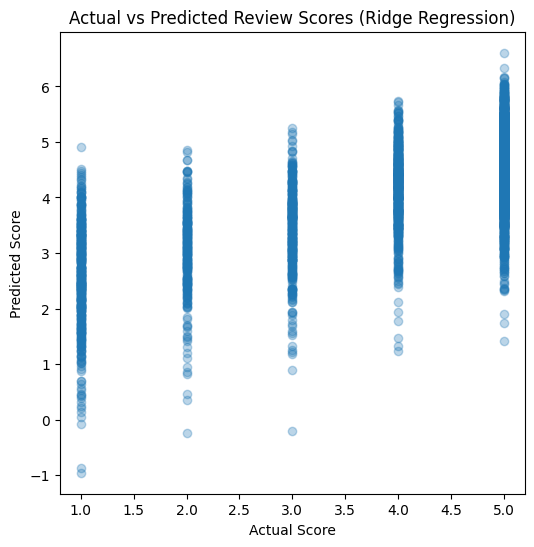

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, ridge_pred, alpha=0.3)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Review Scores (Ridge Regression)")
plt.show()

In [22]:
pred_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Linear': lin_pred,
    'Predicted_Ridge': ridge_pred
})

pred_df.head(10)

,Actual,Predicted_Linear,Predicted_Ridge
0,5,4.748786,4.998927
1,2,0.315481,0.858609
2,5,4.149393,4.442818
3,5,5.161288,4.651563
4,3,3.938720,3.585930
5,3,4.372017,4.130194
6,5,5.018987,4.745830
7,5,4.399652,4.398424
8,2,3.390545,3.172423
9,1,2.867863,3.127754
